# 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [18]:
from langchain_core.tools import Tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages
import os
from dotenv import load_dotenv


In [5]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()
vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever()
retriever

VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001D462DC38C0>, search_kwargs={})

In [6]:
retriever.invoke("what are autonomous agents")

[Document(id='089c308f-5c23-4031-ae96-4d884d29c3fd', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [7]:
def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [8]:
retriever_tool_func("what are autonomous agents")

📚 Using RAGRetriever tool


'Boiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.\nFor example, when requested to "develop a novel anticancer drug", the model came up with the following reasoning steps:\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nOr\n@article{weng2023agent,\n  title   = "LLM-powered Autonomous Agents",\n  author  = "Weng, Lilian",\n  journal = "lilianweng.github.io",\n  year    = "2023",\n  month   = "Jun",\n  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"\n}\nReferences#\n[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022\n[2] Yao et al. “Tree of Thoughts: Dliberate P

In [ ]:
retriever_tool = Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant information",
    func=retriever_tool_func
)
retriever_tool

Tool(name='RAGRetriever', description='Use this tool to fetch relevant information', func=<function retriever_tool_func at 0x000001D462FFDE40>)

In [12]:
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\codes\\agent_study\\RAGUdemy\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [26]:
from langchain.chat_models import init_chat_model
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")
llm = init_chat_model("openai:gpt-4o")

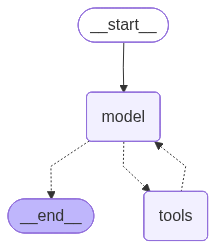

In [31]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------

tools = [retriever_tool, wiki_tool]

from langchain.agents import create_agent
react_node = create_agent(llm, tools)

react_node

In [28]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

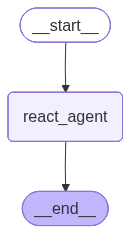

In [32]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------

builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [33]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = graph.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 ### Agent Loop
An agent loop refers to a structured process where an agent, often empowered by large language models (LLMs), continuously learns and evolves through a series of interactions and decision-making processes. The agent loop includes observing the environment, selecting actions, and adjusting behavior based on feedback to improve performance. It involves learning the process of reinforcement learning (RL) rather than training a specific policy.

### Autonomous Agents According to Wikipedia
1. **Autonomous Agent**: This is an artificial intelligence (AI) system that performs complex tasks independently, without human intervention.

2. **AI Agent**: In generative AI, AI agents (or agentic AI) are types of intelligent agents that operate independently in complex environments. They focus on decision-making over content creation and require minimal ongoing oversight.

3. **Intelligent Agent**: This is an entity that perceives its enviro

# Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

## ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [ ]:
import os
from typing import Annotated, Sequence, TypedDict
from langchain_core.tools import Tool
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import WebBaseLoader, ArxivLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [38]:
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000001D462EF4690>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D462EF51D0>, root_client=<openai.OpenAI object at 0x000001D462EF4550>, root_async_client=<openai.AsyncOpenAI object at 0x000001D462EF4410>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [47]:
def make_retriever_tool_from_text(file, name, desc):
    docs = TextLoader(file, encoding="utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50).split_documents(docs)
    vector_store = FAISS.from_documents(chunks, OpenAIEmbeddings())
    retriever = vector_store.as_retriever()
    
    def tool_func(query: str) -> str:
        print(f"📚 Using tool: {name}")
        results = retriever.invoke(query)
        return "\n".join([doc.page_content for doc in results])

    return Tool(name=name, description=desc, func=tool_func)

# Wikipedia Tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

def arxiv_search(query: str) -> str:
    print(f"📚 Using tool: ArXiv")
    results = ArxivLoader(query=query).load()
    return "\n\n".join([doc.page_content[:1000] for doc in results[:2]]) or "No results found."

arxiv_tool = Tool(
    name = "ArXivSearch",
    description = "Use this tool to search for academic papers on ArXiv.",
    func = arxiv_search
)

In [51]:
internal_tool_1 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_1

Tool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001D47F4D0D60>)

In [66]:
internal_tool_2=make_retriever_tool_from_text(
    "internal_docs.txt",
    "内部文档",
    "内部文档"
)
internal_tool_2


Tool(name='内部文档', description='内部文档', func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x000001D47F4FFF60>)

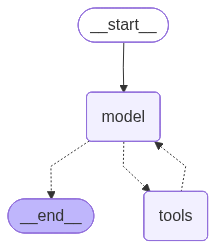

In [67]:
tools = [wiki_tool, arxiv_tool, internal_tool_1, internal_tool_2]

react_agent = create_agent(llm, tools)
react_agent

In [68]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

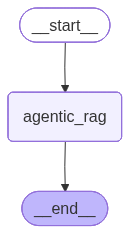

In [69]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph


In [70]:
query = "根据我们的内部文档的内容去ArXiv获取对应的论文并总结"

state = {"messages": [HumanMessage(content=query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool

✅ Final Answer:
 Here are the key summaries of the documents related to the topics specified in your internal notes:

1. **Chain of Thought Prompting and Tree of Thoughts in LLMs**:
   - Chain of thought prompting and tree-of-thought prompting are techniques in prompt engineering. These methods are part of AI language model training and operation strategies that focus on encouraging LLMs to exhibit reasoning capabilities. The chain of thought prompting aids in eliciting step-by-step reasoning from LLMs, while the tree of thought allows models to explore multiple pathways of thought simultaneously, enhancing problem-solving effectiveness.

2. **LLM-Powered Autonomous Agents**:
   - LLM-powered autonomous agents leverage large language models for enhancing autonomous design, planning, and execution in various domains, including scientific research. These agents integrate tools for browsing the internet, executing code, and interfacing with external APIs, optimi